# The Helmholtz Machine — Academic Summary

**Authors:** Peter Dayan, Geoffrey E. Hinton, Radford M. Neal, Richard S. Zemel (1995)

# https://www.cs.toronto.edu/~fritz/absps/helmholtz.pdf

## Abstract
The paper introduces the Helmholtz Machine, a layered stochastic neural network that learns to discover the underlying causal structure of a set of input patterns by jointly training a top-down generative model and a bottom-up recognition model. Because exact maximum-likelihood learning is intractable for generative models with exponentially many possible explanations per pattern, the authors propose maximizing a tractable lower bound (the Helmholtz free energy) on the log-likelihood, using a simple, local, and biologically plausible learning rule.

## Problems
- Maximum-likelihood fitting of hierarchical generative models requires summing over an exponential number of latent "explanations" for each observed pattern, making the Expectation–Maximization (EM) algorithm computationally intractable.
- The true posterior distribution over explanations, $P(\alpha \mid \theta, d)$, generally cannot be factored into simple, independent per-unit distributions, preventing efficient inference.
- Prior self-supervised or analysis-by-synthesis approaches either relied on expensive iterative sampling (e.g., Markov chain Monte Carlo) or lacked a principled statistical objective.

## Proposed Solutions
- Approximate the intractable true posterior $P$ with a tractable, factorial (fully independent within each layer) recognition distribution $Q$, parameterized by a separate set of bottom-up weights $\phi$.
- Optimize a lower bound on the log-likelihood — the negative Helmholtz free energy $\mathcal{F}$ — instead of the true log-likelihood, guaranteeing a valid (if conservative) objective:
$$
\log p(d\mid\theta) = \mathcal{F}(d;\theta,\phi) + \sum_{\alpha} Q_\alpha \log\frac{Q_\alpha}{P_\alpha}
$$
- Introduce the **Deterministic Helmholtz Machine**, which computes derivatives of $\mathcal{F}$ in closed form via backpropagation through mean-field activation probabilities.
- Introduce the **Stochastic Helmholtz Machine**, using a biologically inspired **wake-sleep algorithm**: in the wake phase, bottom-up recognition weights infer causes from real data and top-down generative weights are trained to reconstruct them; in the sleep phase, the network generates "fantasy" data top-down and trains the recognition weights to invert this generative process.

## Purpose
The primary aim is to develop a computationally tractable, purely local (no backpropagated error signals across many layers required in the stochastic variant), and unsupervised learning procedure for hierarchical generative models, motivated by the goal of explaining how the cortex might implement analysis-by-synthesis via reciprocal bottom-up (recognition) and top-down (generative) cortical pathways.

## Methodology
- **Architecture:** Multi-layer networks of binary stochastic units connected via two separate weight sets — generative weights $\theta$ (top-down) and recognition weights $\phi$ (bottom-up).
- **Recognition model:** Computes factorial probabilities $q_j^\ell$ via sigmoid activation:
$$
q_j^\ell(\phi, s^{\ell-1}) = \sigma\left(\sum_i s_i^{\ell-1}\phi_{i,j}^{\ell-1,\ell}\right)
$$
- **Generative model:** Uses an "imaging model" (noisy-OR–derived, competitive weighting scheme) rather than a simple sigmoid, since the sigmoid empirically produced poor local minima; this is detailed in Appendix A (Equations 17–19).
- **Objective:** The free energy is expressed as a sum of layer-wise Kullback-Leibler divergences between recognition and generative distributions:
$$
-\mathcal{F}(\theta,\phi) = \sum_d \sum_\ell \sum_j \mathrm{KL}[q_j^\ell(\phi, q^{\ell-1}), p_j^\ell(\theta, q^{\ell+1})]
$$
- **Deterministic variant:** Learning proceeds via exact gradient computation (chain rule, Appendix B) since generative weights do not influence unit activities, avoiding learning cycles.
- **Stochastic (wake-sleep) variant:** Uses the delta rule in both phases; wake phase trains $\theta$ using data-driven activations, sleep phase trains $\phi$ using self-generated ("fantasized") activations from the current generative model.
- **Benchmark task:** The "shifter problem" — 8-pixel binary rows with a shifted, redundant copy — used to test whether the network recovers the correct two-stage hierarchical generative structure (shift direction and per-pixel activation).

## Results
- The Deterministic Helmholtz Machine successfully learns to extract structure in the shifter problem, with clear qualitative differences between generative and recognition weights (e.g., recognition weights develop inhibitory side-lobes to prevent misclassification).
- Layer 3 units become shift-direction tuned, and layer 2 units become locally responsive to specific shifted pixel pairs, demonstrating recovery of the correct hierarchical causal structure.
- The imaging model (Equations 18–19) substantially outperforms the naive sigmoid generative rule, which tended to become trapped in local minima.
- The wake-sleep algorithm yields identical (local delta-rule) updates in both phases when sigmoid activations are used, offering a simple, biologically plausible mechanism, though it lacks a single unified cost function and does not follow the exact gradient.
- Preliminary unpublished results (attributed to Brendan Frey) indicate the algorithm performs well on additional non-trivial tasks.

## Conclusions
- The Helmholtz Machine provides a tractable framework for unsupervised hierarchical learning by replacing exact posterior inference with a factorial approximation and optimizing a free-energy lower bound, connecting maximum-likelihood learning to statistical mechanics concepts (Boltzmann distributions, KL divergence).
- The separate recognition model allows fast, non-iterative inference at recognition time, addressing the biological implausibility of MCMC-based analysis-by-synthesis models.
- The approach unifies and extends earlier self-supervised learning frameworks (e.g., Zemel, Hinton & Zemel) into a fully hierarchical, multi-layer setting.
- Despite its approximations (factorial recognition distribution, mean-field simplifications, non-convergent wake-sleep dynamics), the model demonstrates the plausibility of a purely local, bidirectional (generative/recognition) learning scheme, with potential relevance to understanding cortical bottom-up/top-down processing pathways.
- The paper identifies open challenges, including the lack of a single joint cost function for the wake-sleep procedure and the need for iterative (within-layer) recognition to capture interactions ignored by the purely feedforward recognition process.

# Mathematical and Statistical Content of "The Helmholtz Machine"

## 1. Log-Likelihood via Marginalization over Explanations
$$
\log p(d\mid\theta) = \log\left(\sum_\alpha p(\alpha\mid\theta)\,p(d\mid\alpha,\theta)\right)
$$
The probability of an observed pattern $d$ is obtained by summing over all possible latent "explanations" $\alpha$ (hidden-unit configurations). This sum has exponentially many terms, which is the core computational obstacle the paper addresses.

## 2. Energy of an Explanation
$$
E_\alpha(\theta,d) = -\log p(\alpha\mid\theta)\,p(d\mid\alpha,\theta)
$$
Borrowing from statistical physics, each explanation is assigned an "energy" — low energy corresponds to a high-probability (good) explanation of the data.

## 3. Boltzmann (Posterior) Distribution
$$
P_\alpha(\theta,d) = \frac{p(\alpha\mid\theta)p(d\mid\alpha,\theta)}{\sum_{\alpha'}p(\alpha'\mid\theta)p(d\mid\alpha',\theta)} = \frac{e^{-E_\alpha}}{\sum_{\alpha'} e^{-E_{\alpha'}}}
$$
This is simply the true posterior probability of an explanation given the data, rewritten in an energy-based (Boltzmann) form to connect with physics-style free-energy reasoning.

## 4. Helmholtz Free Energy Decomposition
$$
\log p(d\mid\theta) = -\left[\sum_\alpha P_\alpha E_\alpha - \left(-\sum_\alpha P_\alpha \log P_\alpha\right)\right]
$$
The log-likelihood is rewritten as negative expected energy plus entropy of the posterior — the classic thermodynamic free energy identity. It shows the likelihood computation still requires the (intractable) true posterior $P$.

## 5. Variational Free Energy with an Approximate Posterior $Q$
$$
\log p(d\mid\theta) = -\sum_\alpha Q_\alpha E_\alpha - \sum_\alpha Q_\alpha \log Q_\alpha + \sum_\alpha Q_\alpha \log\frac{Q_\alpha}{P_\alpha} = \mathcal{F}(d;\theta,Q) + \sum_\alpha Q_\alpha \log\frac{Q_\alpha}{P_\alpha}
$$
This is the paper's key mathematical device (a precursor to the modern Evidence Lower Bound / ELBO). A tractable approximate distribution $Q$ replaces the true posterior $P$. The remaining term is the Kullback-Leibler (KL) divergence between $Q$ and $P$, which is always non-negative. Dropping it yields:
$$
\log p(d\mid\theta) \ge \mathcal{F}(d;\theta,Q)
$$
So $\mathcal{F}$ is a guaranteed lower bound on the true log-likelihood, and it can be maximized instead of the intractable exact likelihood.

## 6. Factorial Recognition Model (Sigmoid Activation)
$$
q_j^\ell(\phi, s^{\ell-1}) = \sigma\left(\sum_i s_i^{\ell-1}\phi_{i,j}^{\ell-1,\ell}\right), \qquad \sigma(x) = \frac{1}{1+e^{-x}}
$$
The recognition (bottom-up) probability that a unit is "on" is a sigmoid function of a weighted sum of the layer below — a standard neural-network activation. The independence ("factorial") assumption means each unit's activity is treated as conditionally independent of others in its layer, given the layer below, drastically simplifying the distribution from $2^h-1$ parameters to $h$ parameters per layer.

## 7. Factorial Joint Recognition Distribution
$$
Q(\alpha,d) = \prod_{\ell>1}\prod_j \left(q_j^\ell\right)^{s_j^\ell}\left(1-q_j^\ell\right)^{1-s_j^\ell}
$$
This expresses the probability of an entire explanation (assignment of all hidden unit states) as a product of independent Bernoulli probabilities — the practical form of the factorial assumption in Eq. 6.

## 8. Generative Model (Top-Down Sigmoid, Later Replaced)
$$
p_j^\ell(\theta, s^{\ell+1}) = \sigma\left(\sum_i s_k^{\ell+1}\theta_{k,j}^{\ell+1,\ell}\right)
$$
Analogous to the recognition model but running top-down: predicts the probability of each unit's state from the layer above. The paper notes this simple sigmoid rule performed poorly in practice.

## 9. Full Generative Probability of an Explanation
$$
p(\alpha\mid\theta) = \prod_{\ell>1}\prod_j \left(p_j^\ell\right)^{s_j^\ell}\left(1-p_j^\ell\right)^{1-s_j^\ell}, \qquad
p(d\mid\alpha,\theta) = \prod_j \left(p_j^1\right)^{s_j^1}\left(1-p_j^1\right)^{1-s_j^1}
$$
These combine to give the total generative probability of both the hidden causes and the visible data, factorized layer by layer (including the input layer).

## 10. Energy in Terms of Layerwise Cross-Entropy
$$
E_\alpha(\theta,d) = -\sum_{\ell\ge1}\sum_j \left[s_j^\ell \log p_j^\ell + (1-s_j^\ell)\log(1-p_j^\ell)\right]
$$
This is the negative log-likelihood (cross-entropy) of the sampled binary states under the generative model — a standard binary cross-entropy loss, summed across all layers and units.

## 11. Free Energy Estimate from a Sampled Explanation
$$
\mathcal{F}_\alpha(d;\theta,\phi) = E_\alpha + \log Q_\alpha = \sum_\ell\sum_j \left[s_j^\ell \log\frac{q_j^\ell}{p_j^\ell} + (1-s_j^\ell)\log\frac{1-q_j^\ell}{1-p_j^\ell}\right]
$$
A Monte Carlo (single-sample) estimator of the free energy objective, obtained by drawing one explanation $\alpha$ from $Q$ and evaluating $\log p / \log q$ ratios. This could in principle be optimized via REINFORCE-style stochastic gradient ascent.

## 12. Mean-Field Approximation
$$
q_j^\ell(\phi,\mathbf{q}^{\ell-1}) = \sigma\left(\sum_i q_i^{\ell-1}\phi_{i,j}^{\ell-1,\ell}\right)
$$
Instead of using sampled binary values $s_j^\ell$ (0 or 1), the deterministic Helmholtz Machine substitutes their expected values (probabilities) $q_j^\ell$ — the standard mean-field approximation used to avoid stochastic sampling noise and enable deterministic gradient computation.

## 13. Free Energy as Sum of KL Divergences
$$
-\mathcal{F}(\theta,\phi) = \sum_d \sum_\ell \sum_j \mathrm{KL}\left[q_j^\ell(\phi,\mathbf{q}^{\ell-1}),\, p_j^\ell(\theta,\mathbf{q}^{\ell+1})\right]
$$
with the Kullback-Leibler divergence between two Bernoulli distributions defined as:
$$
\mathrm{KL}[q,p] = q\log\frac{q}{p} + (1-q)\log\frac{1-q}{1-p}
$$
This reformulates the total learning objective as the sum, over every unit in every layer and every training example, of the KL divergence between the bottom-up (recognition) belief and the top-down (generative) prediction for that unit. Minimizing this divergence is the essence of training.

## 14. Backpropagated Derivative for Deterministic Learning
$$
\frac{\partial \mathcal{F}(d;\theta,\phi)}{\partial q_j^\ell} = \log\frac{1-p_j^\ell}{p_j^\ell}\cdot\frac{1-q_j^\ell}{q_j^\ell} + \sum_i \frac{p_i^{\ell-1}-q_i^{\ell-1}}{p_i^{\ell-1}(1-p_i^{\ell-1})}\frac{\partial p_i^{\ell-1}}{\partial q_j^\ell} + \sum_{\wp>\ell}\sum_k \frac{\partial \mathcal{F}(d;\theta,\phi)}{\partial q_k^\wp}\frac{\partial q_k^\wp}{\partial q_j^\ell}
$$
The gradient of the free energy with respect to each unit's activation is computed recursively via the chain rule (analogous to backpropagation), accumulating contributions from both the layer below (through the generative prediction) and all higher layers (through recognition dependencies). This enables exact gradient-based training of the deterministic machine.

## 15. Imaging Model: Noisy-OR Rule
$$
p_j^\ell(\theta,s^{\ell+1}) = 1 - \prod_k \left(1 - s_k^{\ell+1}\theta_{k,j}^{\ell+1,\ell}\right)
$$
An alternative generative activation rule (from Pearl's noisy-OR model) where weights $\theta \in [0,1]$ represent probabilities that one cause independently triggers an effect. This performed better than the plain sigmoid but still had local-minima issues.

## 16. Imaging Model: Odds-Based (Competitive) Rule
$$
p_j^\ell(\theta,s^{\ell+1}) = 1 - \frac{1}{1+\sum_k s_k^{\ell+1}\theta_{k,j}^{\ell+1,\ell}}
$$
A more competitive rule where weights are interpreted as odds rather than probabilities; multiple active causes combine multiplicatively in their odds contribution rather than independently, which the authors found more effective for the shifter task.

## 17. Deterministic (Mean-Field) Version of the Imaging Model
$$
p_j^\ell(\theta,\mathbf{q}^{\ell+1}) = \left(1-\frac{1}{1+\sum_k q_k^{\ell+1}\theta_{k,j}^{\ell+1,\ell}}\right)\left(1-\prod_k\left(1-q_k^{\ell+1}\frac{\theta_{k,j}^{\ell+1,\ell}}{1+\theta_{k,j}^{\ell+1,\ell}}\right)\right)
$$
Since the odds-based rule (Eq. 18) does not have a simple deterministic (expected-value) counterpart, the authors combine it multiplicatively with the deterministic noisy-OR term to produce a workable generative activation function for use with mean-field probabilities instead of binary samples. This is the actual rule used in the reported experiments.

## 18. Derivatives of the Imaging Model
$$
\frac{\partial p_i^{\ell-1}}{\partial q_j^\ell} \quad \text{and} \quad \frac{\partial p_i^{\ell-1}}{\partial \theta_{j,i}^{\ell,\ell-1}}
$$
(Equations 21–22) — Explicit closed-form partial derivatives of the imaging model with respect to unit activations and generative weights, required to compute gradients through the composite (odds × noisy-OR) generative rule via the chain rule in Eq. 20.

## Summary of Roles

| Concept | Role in Paper |
|---|---|
| Marginal likelihood (Eq. 1) | States the intractable learning objective |
| Energy / Boltzmann distribution (Eqs. 2–3) | Reframes probability as physics-style energy for analogy with free energy |
| Free energy decomposition (Eq. 4–5) | Derives a tractable variational lower bound (ELBO precursor) on log-likelihood |
| KL divergence | Measures mismatch between approximate ($Q$) and true ($P$) posterior; also the final training loss (Eq. 16) |
| Sigmoid activations (Eqs. 6, 8) | Define recognition and (initial) generative models |
| Factorial distributions (Eq. 7, 9–10) | Enable tractable, independent per-unit probability computation |
| Cross-entropy energy (Eqs. 11–14) | Connects generative modeling to standard log-loss training objectives |
| Mean-field approximation (Eq. 15) | Replaces stochastic sampling with expected activations for deterministic gradients |
| Backpropagation-style derivatives (Eqs. 20–22) | Provide the exact gradient computation procedure for the deterministic machine |
| Imaging models (Eqs. 17–19) | Alternative generative activation functions designed to avoid poor local minima found with plain sigmoids |

# Key Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Computing the exact log-likelihood $\log p(d\mid\theta) = \log\sum_\alpha p(\alpha\mid\theta)p(d\mid\alpha,\theta)$ requires summing over exponentially many latent "explanations" $\alpha$ for each pattern. | Standard maximum-likelihood approaches such as the EM algorithm (Dempster et al., 1977) become computationally intractable for all but the simplest generative models, since the E-step cannot enumerate all explanations. | Introduce a tractable lower bound on the log-likelihood — the Helmholtz free energy $\mathcal{F}(d;\theta,Q)$ — and maximize this bound instead of the exact likelihood, guaranteed valid since the omitted KL term is non-negative. |
| 2 | The true posterior over explanations $P(\alpha\mid\theta,d)$ generally cannot be factored into a product of simple, independent unit-wise distributions. | Without a tractable posterior, computing expectations needed for gradient-based learning (e.g., in EM) is infeasible for deep, distributed (multi-cause) hierarchical models. | Approximate the true posterior with a tractable **factorial recognition distribution** $Q$, parameterized by separate bottom-up ("recognition") weights $\phi$, learned jointly with the generative weights $\theta$. |
| 3 | Prior analysis-by-synthesis models for stochastic generative processes typically require inverting the generative model at recognition time via iterative sampling (e.g., Markov chain Monte Carlo, Neal 1992). | MCMC-based inversion is computationally expensive and requires repeated sampling, making it biologically implausible as a model of real-time cortical recognition, which must operate under strict time constraints. | Use a separate, explicit recognition model with bottom-up weights that performs inference in a single non-iterative (feedforward) pass, eliminating the need for sampling-based inversion at recognition time. |
| 4 | The generative activation function (sigmoid, Eq. 8) does not scale well: learning with sigmoid-based generative weights repeatedly becomes trapped in poor local minima, even on relatively simple problems like the shifter task. | Prior single-layer generative work (Saund, 1994a;b) identified this local-minima issue but only in non-hierarchical, non-recognition-model settings; a robust hierarchical solution was lacking. | Introduce alternative "imaging models" — a noisy-OR rule (Eq. 17) and a more competitive odds-based rule (Eq. 18), plus a deterministic mean-field variant combining both (Eq. 19) — that empirically avoid local minima better than the plain sigmoid. |
| 5 | Exact gradient computation for a hierarchical stochastic network is complicated, since changes in one layer's activity affect the generative priors of layers below and recognition activities of layers above. | Naively differentiating through a deep stochastic hierarchy is analytically cumbersome and computationally costly, limiting scalability of earlier self-supervised schemes (e.g., Zemel, 1994; Hinton & Zemel, 1994) to shallow architectures. | Derive closed-form recursive derivatives (Eqs. 20–22) for the deterministic Helmholtz Machine, computable via a single backward propagation pass through the network, analogous to standard backpropagation. |
| 6 | No single, unified cost function exists for training recognition and generative weights via a simple, biologically plausible, purely local learning rule. | Backpropagation-style exact gradients (as in the deterministic machine) require non-local error signals across many layers, which is considered implausible as a model of cortical learning. | Propose the **wake-sleep algorithm**: alternating "wake" (data-driven, train generative weights) and "sleep" (fantasy-driven, train recognition weights) phases, both using the same purely local delta rule, at the cost of no longer following the exact gradient of a single objective. |
| 7 | Purely bottom-up (feedforward) recognition ignores lateral interactions within a layer and top-down influence during recognition itself. | Real cortical perception is believed to involve interactive top-down/bottom-up dynamics, which a strictly feedforward recognition model cannot capture, limiting biological realism. | Identify (as future work) the potential for **iterative recognition** with locally clustered units (excitation/inhibition), acknowledging the added complexity of ensuring stable, fast convergence. |

In [1]:
# ==================================================================================
# Educational Replication: "Autoencoders, Minimum Description Length and Helmholtz
# Free Energy" (Hinton & Zemel, 1994) — Factorial Stochastic Vector Quantization
# Autoencoder, adapted to CIFAR-10.
#
# This is an EDUCATIONAL, SIMPLIFIED reproduction of the paper's core ideas:
#   - A recognition network maps an input to a distribution over discrete codes.
#   - A generative network reconstructs the input from a sampled code.
#   - The code is distributed across several INDEPENDENT categorical "pools"
#     (the paper's factorial code), so the overall code space grows
#     exponentially (6^4 here) without ever being enumerated.
#   - Training minimizes an MDL-inspired Helmholtz free-energy objective:
#         F = reconstruction_cost + code_cost - entropy
#     instead of ordinary reconstruction loss.
#   - The recognition distribution q(h|x) is a tractable, factorial
#     APPROXIMATION to the true (intractable) posterior over codes —
#     exactly the "recognition distribution" idea central to the paper
#     (and later formalized as the Helmholtz Machine).
#
# NOTE ON HOW THIS DIFFERS FROM OTHER MODELS:
#   - Deterministic autoencoder: has a single fixed bottleneck vector and only
#     minimizes reconstruction error. Here the code is STOCHASTIC and
#     categorical, and the objective explicitly trades off reconstruction
#     accuracy against the DESCRIPTION LENGTH (code cost minus entropy) of
#     the code — this is the MDL principle.
#   - Standard VAE: uses a continuous Gaussian latent with a closed-form KL
#     divergence to a fixed prior. Here the latent is discrete/categorical,
#     factorial across independent pools, and the "code cost" plays the role
#     of the prior-matching term while entropy plays the role of the
#     "bits-back" savings (Hinton & Zemel's argument that a stochastic code
#     can be communicated more cheaply than its raw entropy would suggest,
#     because the receiver can also use the leftover randomness to encode
#     other information — hence "bits back").
#   - VQ-VAE: uses a single vector-quantized codebook index with a
#     commitment loss and straight-through estimator over ONE codebook.
#     Here there are SEVERAL independent codebooks (pools), no commitment
#     loss, and the objective is an explicit free-energy/MDL bound rather
#     than a VQ reconstruction + commitment + codebook loss.
#
# Labels are used ONLY after unsupervised training, for a frozen linear probe.
# ==================================================================================

# !pip -q install datasets scikit-learn

import io
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Rectangle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

from datasets import load_dataset
from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------------
# 0. GLOBAL WHITE VISUAL THEME
# ----------------------------------------------------------------------------------
# The paper predates modern plotting conventions, but for readability and
# publication-style presentation we enforce a clean white theme everywhere.
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "font.size": 10,
    })

set_white_theme()

In [3]:
# ----------------------------------------------------------------------------------
# 1. REPRODUCIBILITY AND DEVICE
# ----------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ----------------------------------------------------------------------------------
# 2. DATASET — HUGGINGFACE CIFAR-10 ONLY
# ----------------------------------------------------------------------------------
print("Loading CIFAR-10 from HuggingFace datasets...")
ds = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split as a standard PyTorch Dataset.
    Only used to produce (image_tensor, integer_label) pairs. Labels are
    NEVER consumed by the unsupervised autoencoder — they are only stored
    here so they can later be used by the frozen linear probe.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        record = self.hf_split[idx]
        img = record["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(record["label"])
        return img_tensor, label


train_dataset_full = HFCifar10Dataset(ds["train"], train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], test_transform)

# Small subsets to keep this educational demo computationally manageable.
N_TRAIN = 2000
N_TEST = 400
train_dataset = Subset(train_dataset_full, list(range(N_TRAIN)))
test_dataset = Subset(test_dataset_full, list(range(N_TEST)))

pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           num_workers=2, pin_memory=pin_mem)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=pin_mem)

In [5]:
# ----------------------------------------------------------------------------------
# 3. INPUT REPRESENTATION HELPERS
# ----------------------------------------------------------------------------------
# The recognition/generative networks operate on a compact, POOLED, and
# UNNORMALIZED (i.e. bounded to [0, 1]) representation of each image, since
# the generative decoder ends in a sigmoid and needs bounded targets.
POOL_SIZE = 16
INPUT_DIM = 3 * POOL_SIZE * POOL_SIZE  # 768

_mean_t = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
_std_t = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)


def make_pooled_targets(images_normalized):
    """
    Takes a batch of ImageNet-normalized 64x64 images and produces a
    bounded [0, 1] flattened reconstruction target of size 768:
        1. Adaptive-average-pool to 16x16 (keeps compute manageable).
        2. Undo the ImageNet normalization ("unnormalize").
        3. Clamp to [0, 1] to get a valid probability-like target for a
           sigmoid decoder.
        4. Flatten to [batch_size, 768].
    """
    pooled = F.adaptive_avg_pool2d(images_normalized, output_size=(POOL_SIZE, POOL_SIZE))
    mean_t = _mean_t.to(pooled.device)
    std_t = _std_t.to(pooled.device)
    unnormalized = pooled * std_t + mean_t
    clamped = torch.clamp(unnormalized, 0.0, 1.0)
    flat = clamped.view(clamped.size(0), -1)
    return flat, clamped  # flat target, and the [B,3,16,16] image for viewing

In [6]:
# ----------------------------------------------------------------------------------
# 4. FACTORIAL STOCHASTIC VECTOR QUANTIZATION AUTOENCODER
# ----------------------------------------------------------------------------------
NUM_POOLS = 4          # number of independent discrete latent factors
UNITS_PER_POOL = 6      # number of alternatives ("units") within each pool
NUM_POSSIBLE_CODES = UNITS_PER_POOL ** NUM_POOLS  # 6^4 = 1296, never enumerated

HIDDEN_DIM = 256


class RecognitionNetwork(nn.Module):
    """
    The RECOGNITION network. Maps an input image (flattened, pooled pixels)
    to a distribution over discrete codes.

    Because a single joint distribution over all 6^4 combined codes would be
    intractable to represent, we make a FACTORIAL APPROXIMATION: the network
    outputs independent logits for each of the 4 pools, and softmax is
    applied independently within each pool. This means the approximate
    posterior factorizes as:
        q(h | x) = q(h_1 | x) * q(h_2 | x) * q(h_3 | x) * q(h_4 | x)
    which is exactly the tractability trick used throughout the paper and
    its Helmholtz Machine successor.
    """
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
                 num_pools=NUM_POOLS, units_per_pool=UNITS_PER_POOL):
        super().__init__()
        self.num_pools = num_pools
        self.units_per_pool = units_per_pool
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
        )
        self.out = nn.Linear(hidden_dim, num_pools * units_per_pool)

    def forward(self, x):
        h = self.net(x)
        logits = self.out(h)
        logits = logits.view(-1, self.num_pools, self.units_per_pool)
        return logits  # [B, NUM_POOLS, UNITS_PER_POOL]


class GenerativeCodebooks(nn.Module):
    """
    The GENERATIVE model. Instead of a conventional MLP decoder, we follow
    the paper's idea of explicit, INSPECTABLE generative weights: each unit
    in each pool owns its own additive contribution to the reconstruction.

    For a selected (one-hot) code z, the reconstruction is:
        reconstruction_logits = bias + sum_v sum_i z[v, i] * W[v, i, :]
    i.e. exactly one "codebook vector" per pool gets added into the
    reconstruction, and the pools combine ADDITIVELY. This additive,
    factorial-contribution structure is what lets the model learn
    COOPERATIVE representations: each pool can specialize in explaining a
    different, complementary aspect of the image.
    """
    def __init__(self, input_dim=INPUT_DIM, num_pools=NUM_POOLS,
                 units_per_pool=UNITS_PER_POOL):
        super().__init__()
        self.num_pools = num_pools
        self.units_per_pool = units_per_pool
        self.input_dim = input_dim
        # [NUM_POOLS, UNITS_PER_POOL, INPUT_DIM]
        self.weights = nn.Parameter(
            torch.randn(num_pools, units_per_pool, input_dim) * 0.02
        )
        self.bias = nn.Parameter(torch.zeros(input_dim))

    def forward_from_onehot(self, z):
        """
        z: [B, NUM_POOLS, UNITS_PER_POOL] one-hot (or near one-hot) codes.
        Returns reconstruction_logits: [B, INPUT_DIM]
        """
        # contribution per pool: [B, NUM_POOLS, INPUT_DIM]
        contributions = torch.einsum("bvi,vid->bvd", z, self.weights)
        summed = contributions.sum(dim=1)  # [B, INPUT_DIM]
        logits = summed + self.bias
        return logits

    def forward_from_probs(self, q):
        """
        Computes the EXPECTED pre-sigmoid reconstruction under the
        recognition probabilities q (mean-field / expected code), following
        the paper's idea of computing exact expectations for linear
        generative units. Since our output nonlinearity is a sigmoid (not
        linear), the mean_reconstruction = sigmoid(mean_logits) below is an
        APPROXIMATION to the true expected reconstruction under stochastic
        codes, not an exact closed form as in the paper's linear-unit case.

        q: [B, NUM_POOLS, UNITS_PER_POOL]
        Returns:
            mean_logits: [B, INPUT_DIM]
            total_variance: [B, INPUT_DIM]  (per-output-dim variance under q)
        """
        # Expected contribution per pool: [B, NUM_POOLS, INPUT_DIM]
        mean_contrib = torch.einsum("bvi,vid->bvd", q, self.weights)
        mean_logits = mean_contrib.sum(dim=1) + self.bias

        # Variance of each pool's contribution (independent pools => variances add)
        # second_moment[v, d] = sum_i q[v,i] * W[v,i,d]^2
        second_moment = torch.einsum("bvi,vid->bvd", q, self.weights ** 2)
        mean_sq = mean_contrib ** 2
        pool_variance = second_moment - mean_sq  # [B, NUM_POOLS, INPUT_DIM]
        pool_variance = torch.clamp(pool_variance, min=0.0)  # numerical safety
        total_variance = pool_variance.sum(dim=1)  # [B, INPUT_DIM]

        return mean_logits, total_variance


class FactorialVQAutoencoder(nn.Module):
    """
    Combines the recognition network and generative codebooks into a single
    module implementing the paper's MDL/free-energy autoencoding scheme.
    """
    def __init__(self):
        super().__init__()
        self.recognition = RecognitionNetwork()
        self.generative = GenerativeCodebooks()

    def encode(self, x, temperature, hard=True):
        """
        Returns:
            logits: [B, NUM_POOLS, UNITS_PER_POOL]
            probs:  [B, NUM_POOLS, UNITS_PER_POOL]  (soft, factorial q(h|x))
            z:      [B, NUM_POOLS, UNITS_PER_POOL]  (stochastic one-hot-ish code)
        We use a straight-through Gumbel-Softmax as a DIFFERENTIABLE MODERN
        STAND-IN for genuine categorical sampling: it produces a hard
        one-hot sample in the forward pass while allowing gradients to flow
        back through the soft probabilities. The paper itself used
        REINFORCE-style stochastic sampling; Gumbel-Softmax is the standard
        contemporary approximation used here purely for tractable training.
        """
        logits = self.recognition(x)
        probs = F.softmax(logits, dim=-1)
        z = F.gumbel_softmax(logits, tau=temperature, hard=hard, dim=-1)
        return logits, probs, z

    def decode_sampled(self, z):
        logits = self.generative.forward_from_onehot(z)
        return torch.sigmoid(logits)

    def decode_expected(self, probs):
        mean_logits, total_variance = self.generative.forward_from_probs(probs)
        mean_reconstruction = torch.sigmoid(mean_logits)
        return mean_reconstruction, total_variance


model = FactorialVQAutoencoder().to(DEVICE)

In [7]:
# ----------------------------------------------------------------------------------
# 5. MDL / HELMHOLTZ FREE-ENERGY OBJECTIVE
# ----------------------------------------------------------------------------------
EPS = 1e-8
PRIOR_PROB = 1.0 / UNITS_PER_POOL  # uniform prior over alternatives in a pool

RECON_WEIGHT = 1.0
CODE_WEIGHT = 0.02
ENTROPY_WEIGHT = 0.02
VARIANCE_WEIGHT = 0.5


def compute_free_energy(target, mean_reconstruction, total_variance, probs):
    """
    Implements the paper's three-part MDL objective:

      A. Expected reconstruction cost: squared error between the EXPECTED
         reconstruction and the target, plus the expected variance under
         stochastic code sampling (an approximate 'expected squared error').
             recon_cost = E[(mean_recon - target)^2] + variance_weight * Var

      B. Code cost: expected number of "nats" needed to describe which code
         was chosen, under a uniform prior over each pool's alternatives.
         This penalizes using codes that would be expensive to communicate.
             code_cost = E_q[-log prior_probability]

      C. Recognition entropy: the entropy of q(h|x). Subtracting it from the
         cost represents the MDL "bits-back" saving: because the code was
         chosen stochastically, whichever code got sampled could in
         principle also encode extra information via the residual
         randomness, and this saved cost is credited back against the
         reconstruction+code cost.

      Free energy = recon_weight * recon_cost
                   + code_weight * code_cost
                   - entropy_weight * entropy

    This upper-bounds the ideal description length ("minimum description
    length") of the input under the recognition-and-generative-model pair,
    exactly analogous to the Helmholtz free energy in the paper's title.
    """
    recon_sq_error = (mean_reconstruction - target) ** 2
    reconstruction_cost = torch.mean(
        torch.sum(recon_sq_error + VARIANCE_WEIGHT * total_variance, dim=1)
    )

    code_cost = torch.mean(
        torch.sum(probs * (-math.log(PRIOR_PROB + EPS)), dim=(1, 2))
    )

    entropy = torch.mean(
        -torch.sum(probs * torch.log(probs + EPS), dim=(1, 2))
    )

    free_energy = (RECON_WEIGHT * reconstruction_cost
                   + CODE_WEIGHT * code_cost
                   - ENTROPY_WEIGHT * entropy)

    return free_energy, reconstruction_cost, code_cost, entropy

In [8]:
# ----------------------------------------------------------------------------------
# 6. DATA SANITY CHECK
# ----------------------------------------------------------------------------------
print("\n--- DATA SANITY CHECK ---")
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

flat_targets, pooled_view = make_pooled_targets(sample_images)
with torch.no_grad():
    s_logits, s_probs, s_z = model.encode(flat_targets, temperature=1.0, hard=True)
    s_recon_sampled = model.decode_sampled(s_z)

print(f"Number of training samples (subset): {len(train_dataset)}")
print(f"Number of test samples (subset): {len(test_dataset)}")
print(f"Original image-batch shape: {tuple(sample_images.shape)}")
print(f"Pooled image shape: {tuple(pooled_view.shape)}")
print(f"Flattened reconstruction-target shape: {tuple(flat_targets.shape)}")
print(f"Label range: [{sample_labels.min().item()}, {sample_labels.max().item()}]")
print(f"First eight integer labels: {sample_labels[:8].tolist()}")
print(f"First eight class names: {[class_names[i] for i in sample_labels[:8].tolist()]}")
print(f"Recognition-logit shape: {tuple(s_logits.shape)}")
print(f"Recognition-probability shape: {tuple(s_probs.shape)}")
print(f"Sampled-code shape: {tuple(s_z.shape)}")
print(f"Reconstruction shape: {tuple(s_recon_sampled.shape)}")
print(f"Number of possible distributed codes: {NUM_POSSIBLE_CODES}")

assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9
assert flat_targets.min().item() >= -1e-5 and flat_targets.max().item() <= 1.0 + 1e-5
assert torch.allclose(s_probs.sum(dim=-1), torch.ones_like(s_probs.sum(dim=-1)), atol=1e-4)
assert torch.allclose(s_z.sum(dim=-1), torch.ones_like(s_z.sum(dim=-1)), atol=1e-3)
assert torch.isfinite(s_recon_sampled).all()
assert s_recon_sampled.min().item() >= -1e-5 and s_recon_sampled.max().item() <= 1.0 + 1e-5
print("All sanity checks passed.\n")


--- DATA SANITY CHECK ---
Number of training samples (subset): 2000
Number of test samples (subset): 400
Original image-batch shape: (64, 3, 64, 64)
Pooled image shape: (64, 3, 16, 16)
Flattened reconstruction-target shape: (64, 768)
Label range: [0, 9]
First eight integer labels: [1, 9, 2, 6, 4, 2, 6, 9]
First eight class names: ['automobile', 'truck', 'bird', 'frog', 'deer', 'bird', 'frog', 'truck']
Recognition-logit shape: (64, 4, 6)
Recognition-probability shape: (64, 4, 6)
Sampled-code shape: (64, 4, 6)
Reconstruction shape: (64, 768)
Number of possible distributed codes: 1296
All sanity checks passed.



In [9]:
# ----------------------------------------------------------------------------------
# 7. OPTIMIZATION SETUP
# ----------------------------------------------------------------------------------
EPOCHS = 5
LEARNING_RATE = 1e-3
TEMPERATURE_SCHEDULE = [1.0, 0.9, 0.8, 0.7, 0.6]

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_free_energy": [], "val_free_energy": [],
    "train_recon_cost": [], "val_recon_cost": [],
    "train_code_cost": [], "val_code_cost": [],
    "train_entropy": [], "val_entropy": [],
    "mean_variance": [],
    "pool_entropy": [],           # list of [NUM_POOLS] per epoch
    "effective_units": [],        # list of [NUM_POOLS] per epoch
    "unit_usage": [],             # list of [NUM_POOLS, UNITS_PER_POOL] per epoch
    "pairwise_mi": [],            # list of [NUM_POOLS, NUM_POOLS] per epoch
    "sampled_mse": [],
    "expected_mse": [],
}

In [10]:
# ----------------------------------------------------------------------------------
# 8. DIAGNOSTIC HELPERS
# ----------------------------------------------------------------------------------
def factoriality_diagnostics(all_probs, all_hard_codes):
    """
    all_probs: [N, NUM_POOLS, UNITS_PER_POOL] soft recognition probabilities
    all_hard_codes: [N, NUM_POOLS, UNITS_PER_POOL] one-hot hard codes

    Returns:
        pool_entropy: [NUM_POOLS] mean entropy per pool
        unit_usage:   [NUM_POOLS, UNITS_PER_POOL] mean usage probability
        effective_units: [NUM_POOLS] exp(entropy of average usage)
        pairwise_mi:  [NUM_POOLS, NUM_POOLS] mutual-information estimate
                      between hard pool assignments
    """
    probs_np = all_probs.detach().cpu().numpy()
    hard_np = all_hard_codes.detach().cpu().numpy()

    # Mean entropy per pool (averaged over examples)
    ent = -np.sum(probs_np * np.log(probs_np + EPS), axis=-1)  # [N, NUM_POOLS]
    pool_entropy = ent.mean(axis=0)  # [NUM_POOLS]

    # Mean usage per unit (average recognition probability)
    unit_usage = probs_np.mean(axis=0)  # [NUM_POOLS, UNITS_PER_POOL]

    # Effective number of active units: exp(entropy of the AVERAGE usage dist)
    avg_dist = unit_usage / (unit_usage.sum(axis=-1, keepdims=True) + EPS)
    avg_entropy = -np.sum(avg_dist * np.log(avg_dist + EPS), axis=-1)
    effective_units = np.exp(avg_entropy)  # [NUM_POOLS]

    # Pairwise mutual information between HARD assignments of pools
    assign = np.argmax(hard_np, axis=-1)  # [N, NUM_POOLS]
    n_pools = assign.shape[1]
    pairwise_mi = np.zeros((n_pools, n_pools))
    for v1 in range(n_pools):
        for v2 in range(n_pools):
            if v1 == v2:
                continue
            joint = np.zeros((UNITS_PER_POOL, UNITS_PER_POOL))
            for i in range(assign.shape[0]):
                joint[assign[i, v1], assign[i, v2]] += 1
            joint = joint / joint.sum()
            p1 = joint.sum(axis=1, keepdims=True)
            p2 = joint.sum(axis=0, keepdims=True)
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = joint / (p1 * p2 + EPS)
                log_ratio = np.log(ratio + EPS)
            mi = np.sum(joint * log_ratio)
            pairwise_mi[v1, v2] = max(mi, 0.0)

    return pool_entropy, unit_usage, effective_units, pairwise_mi

In [11]:
# ----------------------------------------------------------------------------------
# 9. TRAINING LOOP
# ----------------------------------------------------------------------------------
print("--- TRAINING (unsupervised, no labels used) ---")

for epoch in range(EPOCHS):
    temperature = TEMPERATURE_SCHEDULE[min(epoch, len(TEMPERATURE_SCHEDULE) - 1)]

    # ---------------- TRAIN ----------------
    model.train()
    running = {"fe": 0.0, "rc": 0.0, "cc": 0.0, "ent": 0.0, "var": 0.0, "n": 0}

    for images, _labels in train_loader:  # labels intentionally unused here
        images = images.to(DEVICE)
        targets, _ = make_pooled_targets(images)

        logits, probs, z = model.encode(targets, temperature=temperature, hard=True)
        recon_sampled = model.decode_sampled(z)
        mean_recon, total_var = model.decode_expected(probs)

        free_energy, recon_cost, code_cost, entropy = compute_free_energy(
            targets, mean_recon, total_var, probs
        )

        optimizer.zero_grad()
        free_energy.backward()
        optimizer.step()

        bs = images.size(0)
        running["fe"] += free_energy.item() * bs
        running["rc"] += recon_cost.item() * bs
        running["cc"] += code_cost.item() * bs
        running["ent"] += entropy.item() * bs
        running["var"] += total_var.mean().item() * bs
        running["n"] += bs

    train_fe = running["fe"] / running["n"]
    train_rc = running["rc"] / running["n"]
    train_cc = running["cc"] / running["n"]
    train_ent = running["ent"] / running["n"]

    # ---------------- VALIDATION ----------------
    model.eval()
    running_v = {"fe": 0.0, "rc": 0.0, "cc": 0.0, "ent": 0.0, "var": 0.0,
                 "sampled_mse": 0.0, "expected_mse": 0.0, "n": 0}
    all_probs_epoch = []
    all_hard_epoch = []

    with torch.no_grad():
        for images, _labels in test_loader:
            images = images.to(DEVICE)
            targets, _ = make_pooled_targets(images)

            logits, probs, z = model.encode(targets, temperature=temperature, hard=True)
            recon_sampled = model.decode_sampled(z)
            mean_recon, total_var = model.decode_expected(probs)

            free_energy, recon_cost, code_cost, entropy = compute_free_energy(
                targets, mean_recon, total_var, probs
            )

            bs = images.size(0)
            running_v["fe"] += free_energy.item() * bs
            running_v["rc"] += recon_cost.item() * bs
            running_v["cc"] += code_cost.item() * bs
            running_v["ent"] += entropy.item() * bs
            running_v["var"] += total_var.mean().item() * bs
            running_v["sampled_mse"] += F.mse_loss(recon_sampled, targets, reduction="sum").item()
            running_v["expected_mse"] += F.mse_loss(mean_recon, targets, reduction="sum").item()
            running_v["n"] += bs

            all_probs_epoch.append(probs.cpu())
            all_hard_epoch.append(z.cpu())

    val_fe = running_v["fe"] / running_v["n"]
    val_rc = running_v["rc"] / running_v["n"]
    val_cc = running_v["cc"] / running_v["n"]
    val_ent = running_v["ent"] / running_v["n"]
    val_var = running_v["var"] / running_v["n"]
    val_sampled_mse = running_v["sampled_mse"] / (running_v["n"] * INPUT_DIM)
    val_expected_mse = running_v["expected_mse"] / (running_v["n"] * INPUT_DIM)

    all_probs_epoch = torch.cat(all_probs_epoch, dim=0)
    all_hard_epoch = torch.cat(all_hard_epoch, dim=0)
    pool_ent, unit_usage, eff_units, pw_mi = factoriality_diagnostics(
        all_probs_epoch, all_hard_epoch
    )

    history["train_free_energy"].append(train_fe)
    history["val_free_energy"].append(val_fe)
    history["train_recon_cost"].append(train_rc)
    history["val_recon_cost"].append(val_rc)
    history["train_code_cost"].append(train_cc)
    history["val_code_cost"].append(val_cc)
    history["train_entropy"].append(train_ent)
    history["val_entropy"].append(val_ent)
    history["mean_variance"].append(val_var)
    history["pool_entropy"].append(pool_ent)
    history["effective_units"].append(eff_units)
    history["unit_usage"].append(unit_usage)
    history["pairwise_mi"].append(pw_mi)
    history["sampled_mse"].append(val_sampled_mse)
    history["expected_mse"].append(val_expected_mse)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_FE={train_fe:.4f} | val_FE={val_fe:.4f} | "
          f"val_recon={val_rc:.4f} | val_code={val_cc:.4f} | val_ent={val_ent:.4f}")

print("Training complete.\n")

--- TRAINING (unsupervised, no labels used) ---
Epoch 1/5 | train_FE=44.2758 | val_FE=44.8124 | val_recon=44.6723 | val_code=7.1670 | val_ent=0.1618
Epoch 2/5 | train_FE=43.2912 | val_FE=43.7053 | val_recon=43.5653 | val_code=7.1670 | val_ent=0.1655
Epoch 3/5 | train_FE=42.3377 | val_FE=42.6478 | val_recon=42.5103 | val_code=7.1670 | val_ent=0.2904
Epoch 4/5 | train_FE=41.0921 | val_FE=41.2675 | val_recon=41.1415 | val_code=7.1670 | val_ent=0.8688
Epoch 5/5 | train_FE=39.5800 | val_FE=39.7121 | val_recon=39.5740 | val_code=7.1670 | val_ent=0.2655
Training complete.



In [12]:
# ----------------------------------------------------------------------------------
# 10. FULL EVALUATION PASS (collect everything needed for visualization)
# ----------------------------------------------------------------------------------
model.eval()
eval_store = {
    "inputs": [], "labels": [], "probs": [], "hard_codes": [],
    "mean_recon": [], "sampled_recon": [], "recon_error": [],
}

final_temp = TEMPERATURE_SCHEDULE[-1]

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        targets, pooled_imgs = make_pooled_targets(images)

        logits, probs, z = model.encode(targets, temperature=final_temp, hard=True)
        recon_sampled = model.decode_sampled(z)
        mean_recon, total_var = model.decode_expected(probs)
        recon_error = torch.mean((mean_recon - targets) ** 2, dim=1)

        eval_store["inputs"].append(targets.cpu())
        eval_store["labels"].append(labels)
        eval_store["probs"].append(probs.cpu())
        eval_store["hard_codes"].append(z.cpu())
        eval_store["mean_recon"].append(mean_recon.cpu())
        eval_store["sampled_recon"].append(recon_sampled.cpu())
        eval_store["recon_error"].append(recon_error.cpu())

for k in eval_store:
    eval_store[k] = torch.cat(eval_store[k], dim=0)

test_labels_np = eval_store["labels"].numpy()

In [13]:
# ----------------------------------------------------------------------------------
# 11. REUSABLE ENCODE / RECONSTRUCT PIPELINE FUNCTIONS
# ----------------------------------------------------------------------------------
def encode_images(images_normalized, temperature=final_temp, hard=True):
    """
    images_normalized: [B, 3, 64, 64] (ImageNet-normalized) tensor on any device.
    Returns dict with logits, probs, hard_codes, flattened latent representation.
    """
    images_normalized = images_normalized.to(DEVICE)
    targets, _ = make_pooled_targets(images_normalized)
    with torch.no_grad():
        logits, probs, z = model.encode(targets, temperature=temperature, hard=hard)
    flat_latent = probs.view(probs.size(0), -1)
    return {
        "logits": logits.cpu(),
        "probs": probs.cpu(),
        "hard_codes": z.cpu(),
        "flat_latent": flat_latent.cpu(),
    }


def reconstruct_images(images_normalized, deterministic=True):
    """
    Returns expected reconstruction, sampled reconstruction, and per-example
    reconstruction error (MSE against the bounded pooled target).
    """
    images_normalized = images_normalized.to(DEVICE)
    targets, _ = make_pooled_targets(images_normalized)
    with torch.no_grad():
        logits, probs, z = model.encode(targets, temperature=final_temp, hard=True)
        mean_recon, total_var = model.decode_expected(probs)
        sampled_recon = model.decode_sampled(z)
        error = torch.mean((mean_recon - targets) ** 2, dim=1)
    return {
        "expected_reconstruction": mean_recon.cpu(),
        "sampled_reconstruction": sampled_recon.cpu(),
        "reconstruction_error": error.cpu(),
    }

In [14]:
# ----------------------------------------------------------------------------------
# 12. LINEAR PROBE ON FROZEN UNSUPERVISED CODES
# ----------------------------------------------------------------------------------
print("--- LINEAR PROBE ON FROZEN UNSUPERVISED CODES ---")


def extract_latent_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for images, lbls in loader:
            enc = encode_images(images)
            feats.append(enc["flat_latent"])
            labels.append(lbls)
    return torch.cat(feats, dim=0).numpy(), torch.cat(labels, dim=0).numpy()


train_feats, train_lbls = extract_latent_features(train_loader)
test_feats, test_lbls = extract_latent_features(test_loader)

probe = LogisticRegression(max_iter=2000, multi_class="auto")
probe.fit(train_feats, train_lbls)

probe_train_pred = probe.predict(train_feats)
probe_test_pred = probe.predict(test_feats)
probe_test_proba = probe.predict_proba(test_feats)

probe_train_acc = accuracy_score(train_lbls, probe_train_pred)
probe_val_acc = accuracy_score(test_lbls, probe_test_pred)

cm = confusion_matrix(test_lbls, probe_test_pred, labels=list(range(10)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + EPS)

per_class_acc = np.diag(cm) / (cm.sum(axis=1) + EPS)

confidences = probe_test_proba[np.arange(len(test_lbls)), probe_test_pred]
correct_mask = probe_test_pred == test_lbls
mean_conf_correct = confidences[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
mean_conf_incorrect = confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else float("nan")

print("Linear probe on frozen unsupervised codes:")
print(f"  Training accuracy:  {probe_train_acc:.4f}")
print(f"  Validation accuracy: {probe_val_acc:.4f}")

sorted_class_idx = np.argsort(-per_class_acc)
top3_classes = [class_names[i] for i in sorted_class_idx[:3]]
bottom3_classes = [class_names[i] for i in sorted_class_idx[-3:]]


def linear_probe_predict(images_normalized):
    """
    Returns dict with probe class probabilities, predicted labels, predicted
    class names, confidence scores, and latent codes — using the FROZEN
    autoencoder + a separately trained linear probe. Does not affect the
    autoencoder in any way.
    """
    enc = encode_images(images_normalized)
    feats = enc["flat_latent"].numpy()
    proba = probe.predict_proba(feats)
    preds = probe.predict(feats)
    conf = proba[np.arange(len(preds)), preds]
    pred_names = [class_names[p] for p in preds]
    return {
        "probabilities": proba,
        "predicted_labels": preds,
        "predicted_class_names": pred_names,
        "confidence": conf,
        "latent_codes": enc["hard_codes"],
    }

--- LINEAR PROBE ON FROZEN UNSUPERVISED CODES ---
Linear probe on frozen unsupervised codes:
  Training accuracy:  0.1635
  Validation accuracy: 0.1450


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [15]:
# ----------------------------------------------------------------------------------
# 13. UTILITY: reshape flattened [768] vectors back into [3, 16, 16] images
# ----------------------------------------------------------------------------------
def to_image(flat_vec):
    """flat_vec: [768] -> numpy array [16, 16, 3] in [0, 1] for imshow."""
    img = flat_vec.view(3, POOL_SIZE, POOL_SIZE).permute(1, 2, 0).numpy()
    return np.clip(img, 0.0, 1.0)

In [16]:
# ==================================================================================
# 14. STANDALONE VISUALIZATIONS (1 through 16)
# ==================================================================================
set_white_theme()
epochs_range = np.arange(1, EPOCHS + 1)

# ---- 1. Free-energy curves ----
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_free_energy"], label="Train", marker="o")
ax1.plot(epochs_range, history["val_free_energy"], label="Validation", marker="o")
ax1.set_title("Total Helmholtz Free Energy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Free Energy")
ax1.grid(True); ax1.legend()
plt.tight_layout(); plt.close(fig1)

# ---- 2. Reconstruction-cost curves ----
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_recon_cost"], label="Train", marker="o")
ax2.plot(epochs_range, history["val_recon_cost"], label="Validation", marker="o")
ax2.set_title("Expected Reconstruction Cost")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Cost")
ax2.grid(True); ax2.legend()
plt.tight_layout(); plt.close(fig2)

# ---- 3. Code-cost curves ----
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(epochs_range, history["train_code_cost"], label="Train", marker="o")
ax3.plot(epochs_range, history["val_code_cost"], label="Validation", marker="o")
ax3.set_title("Code Cost (bits of code description)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Cost (nats)")
ax3.grid(True); ax3.legend()
plt.tight_layout(); plt.close(fig3)

# ---- 4. Entropy curves ----
fig4, ax4 = plt.subplots(figsize=(6, 4))
ax4.plot(epochs_range, history["train_entropy"], label="Train", marker="o")
ax4.plot(epochs_range, history["val_entropy"], label="Validation", marker="o")
ax4.set_title("Recognition Distribution Entropy")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Entropy (nats)")
ax4.grid(True); ax4.legend()
plt.tight_layout(); plt.close(fig4)

# ---- 5. Per-pool entropy curves ----
pool_entropy_arr = np.array(history["pool_entropy"])  # [EPOCHS, NUM_POOLS]
fig5, ax5 = plt.subplots(figsize=(6, 4))
for v in range(NUM_POOLS):
    ax5.plot(epochs_range, pool_entropy_arr[:, v], marker="o", label=f"Pool {v+1}")
ax5.set_title("Per-Pool Entropy Over Training")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Entropy (nats)")
ax5.grid(True); ax5.legend()
plt.tight_layout(); plt.close(fig5)

# ---- 6. Effective active-unit curves ----
eff_units_arr = np.array(history["effective_units"])  # [EPOCHS, NUM_POOLS]
fig6, ax6 = plt.subplots(figsize=(6, 4))
for v in range(NUM_POOLS):
    ax6.plot(epochs_range, eff_units_arr[:, v], marker="o", label=f"Pool {v+1}")
ax6.axhline(UNITS_PER_POOL, color="grey", linestyle="--", linewidth=1,
            label="Max possible units")
ax6.set_title("Effective Active Units per Pool")
ax6.set_xlabel("Epoch"); ax6.set_ylabel("Effective units")
ax6.grid(True); ax6.legend()
plt.tight_layout(); plt.close(fig6)

# ---- 7. Original vs expected vs sampled reconstructions ----
n_show = 6
fig7, axes7 = plt.subplots(3, n_show, figsize=(2 * n_show, 6))
for i in range(n_show):
    orig_img = to_image(eval_store["inputs"][i])
    exp_img = to_image(eval_store["mean_recon"][i])
    samp_img = to_image(eval_store["sampled_recon"][i])
    axes7[0, i].imshow(orig_img); axes7[0, i].axis("off")
    axes7[1, i].imshow(exp_img); axes7[1, i].axis("off")
    axes7[2, i].imshow(samp_img); axes7[2, i].axis("off")
    axes7[0, i].set_title(class_names[test_labels_np[i]], fontsize=8)
axes7[0, 0].set_ylabel("Original", fontsize=9)
axes7[1, 0].set_ylabel("Expected", fontsize=9)
axes7[2, 0].set_ylabel("Sampled", fontsize=9)
fig7.suptitle("Original vs. Expected vs. Sampled Reconstructions")
plt.tight_layout(); plt.close(fig7)

# ---- 8. Code-usage heatmap ----
final_unit_usage = history["unit_usage"][-1]  # [NUM_POOLS, UNITS_PER_POOL]
fig8, ax8 = plt.subplots(figsize=(6, 4))
im8 = ax8.imshow(final_unit_usage, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax8.set_title("Factorial Code Usage (Pool x Unit)")
ax8.set_xlabel("Unit within pool"); ax8.set_ylabel("Pool")
ax8.set_xticks(range(UNITS_PER_POOL)); ax8.set_yticks(range(NUM_POOLS))
for v in range(NUM_POOLS):
    for i in range(UNITS_PER_POOL):
        ax8.text(i, v, f"{final_unit_usage[v, i]:.2f}", ha="center", va="center",
                  color="black", fontsize=7)
fig8.colorbar(im8, ax=ax8, label="Mean usage probability")
plt.tight_layout(); plt.close(fig8)

# ---- 9. Per-class latent-pool usage heatmap ----
probs_np_full = eval_store["probs"].numpy()  # [N, NUM_POOLS, UNITS_PER_POOL]
per_class_usage = np.zeros((10, NUM_POOLS, UNITS_PER_POOL))
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        per_class_usage[c] = probs_np_full[mask].mean(axis=0)

fig9, axes9 = plt.subplots(1, NUM_POOLS, figsize=(4 * NUM_POOLS, 4))
for v in range(NUM_POOLS):
    im9 = axes9[v].imshow(per_class_usage[:, v, :], cmap="Greys", vmin=0, vmax=1,
                            aspect="auto")
    axes9[v].set_title(f"Pool {v+1}")
    axes9[v].set_xlabel("Unit")
    axes9[v].set_yticks(range(10))
    axes9[v].set_yticklabels(class_names, fontsize=7)
fig9.suptitle("Per-Class Latent-Pool Usage")
plt.tight_layout(); plt.close(fig9)

# ---- 10. Generative codebook-weight visualization ----
gen_weights = model.generative.weights.detach().cpu()  # [NUM_POOLS, UNITS_PER_POOL, INPUT_DIM]
fig10, axes10 = plt.subplots(NUM_POOLS, UNITS_PER_POOL,
                              figsize=(UNITS_PER_POOL * 1.5, NUM_POOLS * 1.5))
for v in range(NUM_POOLS):
    for i in range(UNITS_PER_POOL):
        w = gen_weights[v, i]
        w_img = w.view(3, POOL_SIZE, POOL_SIZE).permute(1, 2, 0).numpy()
        w_img = (w_img - w_img.min()) / (w_img.max() - w_img.min() + EPS)
        axes10[v, i].imshow(w_img)
        axes10[v, i].axis("off")
        if v == 0:
            axes10[v, i].set_title(f"unit {i}", fontsize=7)
    axes10[v, 0].text(-0.6, 0.5, f"Pool {v+1}", transform=axes10[v, 0].transAxes,
                       fontsize=8, va="center", ha="right")
fig10.suptitle("Generative Codebook Contributions (each tile is one unit's\n"
               "additive contribution to the reconstruction, min-max normalized)")
plt.tight_layout(); plt.close(fig10)

# ---- 11. PCA visualization of latent representations ----
flat_probs = probs_np_full.reshape(probs_np_full.shape[0], -1)  # [N, 24]
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(flat_probs)

fig11, ax11 = plt.subplots(figsize=(6, 5))
scatter = ax11.scatter(pca_coords[:, 0], pca_coords[:, 1], c=test_labels_np,
                        cmap="tab10", s=15, alpha=0.8)
ax11.set_title("PCA of Recognition Probabilities\n(learned without labels)")
ax11.set_xlabel("PC 1"); ax11.set_ylabel("PC 2")
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10(i / 10),
                       label=class_names[i]) for i in range(10)]
ax11.legend(handles=handles, loc="best", fontsize=6, ncol=2)
plt.tight_layout(); plt.close(fig11)

# ---- 12. Pool-dependence matrix ----
final_mi = history["pairwise_mi"][-1]
fig12, ax12 = plt.subplots(figsize=(5, 4))
im12 = ax12.imshow(final_mi, cmap="Greys", aspect="auto")
ax12.set_title("Pairwise Pool Mutual Information (hard assignments)")
ax12.set_xlabel("Pool"); ax12.set_ylabel("Pool")
ax12.set_xticks(range(NUM_POOLS)); ax12.set_yticks(range(NUM_POOLS))
for v1 in range(NUM_POOLS):
    for v2 in range(NUM_POOLS):
        ax12.text(v2, v1, f"{final_mi[v1, v2]:.2f}", ha="center", va="center",
                   fontsize=7, color="black")
fig12.colorbar(im12, ax=ax12, label="MI (nats)")
plt.tight_layout(); plt.close(fig12)

# ---- 13. Linear-probe confusion matrix ----
fig13, ax13 = plt.subplots(figsize=(6, 5))
im13 = ax13.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
ax13.set_title("Linear Probe Confusion Matrix (Frozen Codes)")
ax13.set_xticks(range(10)); ax13.set_yticks(range(10))
ax13.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
ax13.set_yticklabels(class_names, fontsize=7)
ax13.set_xlabel("Predicted"); ax13.set_ylabel("True")
fig13.colorbar(im13, ax=ax13, label="Fraction")
plt.tight_layout(); plt.close(fig13)

# ---- 14. Linear-probe per-class accuracy ----
fig14, ax14 = plt.subplots(figsize=(7, 4))
ax14.bar(class_names, per_class_acc, color="dimgray")
ax14.axhline(probe_val_acc, color="black", linestyle="--", label="Overall accuracy")
ax14.set_title("Linear Probe Per-Class Accuracy (Frozen Codes)")
ax14.set_ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
ax14.legend()
plt.tight_layout(); plt.close(fig14)

# ---- 15. Linear-probe confidence distributions ----
fig15, ax15 = plt.subplots(figsize=(6, 4))
ax15.hist(confidences[correct_mask], bins=15, alpha=0.7, label="Correct",
          color="black")
ax15.hist(confidences[~correct_mask], bins=15, alpha=0.4, label="Incorrect",
          color="grey")
ax15.set_title("Linear Probe Confidence Distribution")
ax15.set_xlabel("Confidence"); ax15.set_ylabel("Count")
ax15.legend()
plt.tight_layout(); plt.close(fig15)

# ---- 16. Sample predictions (>= 12) ----
n_pred_show = 12
fig16, axes16 = plt.subplots(2, 6, figsize=(14, 5))
for idx in range(n_pred_show):
    r, c = divmod(idx, 6)
    img = to_image(eval_store["inputs"][idx])
    true_name = class_names[test_labels_np[idx]]
    pred_name = class_names[probe_test_pred[idx]]
    conf = probe_test_proba[idx, probe_test_pred[idx]]
    axes16[r, c].imshow(img)
    axes16[r, c].axis("off")
    color = "black" if pred_name == true_name else "red"
    axes16[r, c].set_title(f"T:{true_name}\nP:{pred_name} ({conf:.2f})",
                            fontsize=7, color=color)
fig16.suptitle("Linear Probe Sample Predictions (Frozen Unsupervised Codes)")
plt.tight_layout(); plt.close(fig16)

# ---- Nearest-neighbor retrieval (used in the dashboard's supporting analysis) ----
def nearest_neighbors(query_idx, k=5):
    query_vec = flat_probs[query_idx:query_idx + 1]
    dists = np.linalg.norm(flat_probs - query_vec, axis=1)
    order = np.argsort(dists)
    order = order[order != query_idx][:k]
    return order, dists[order]

nn_query_idx = 0
nn_indices, nn_dists = nearest_neighbors(nn_query_idx, k=5)

# ---- Factor-combination demonstration (educational synthetic sample) ----
def synthesize_from_units(unit_indices):
    """
    unit_indices: list/tuple of length NUM_POOLS, one selected unit index per pool.
    Combines the corresponding generative contributions additively and applies
    sigmoid, exactly as the generative model does for a real one-hot code.
    NOTE: This is an educational demonstration of factorial code combination;
    it is NOT guaranteed to produce a realistic-looking image, since the
    codebooks were only ever trained on combinations that arose from actual
    encoded images.
    """
    with torch.no_grad():
        one_hot = torch.zeros(1, NUM_POOLS, UNITS_PER_POOL)
        for v, i in enumerate(unit_indices):
            one_hot[0, v, i] = 1.0
        logits = model.generative.forward_from_onehot(one_hot.to(DEVICE))
        synth = torch.sigmoid(logits).cpu()[0]
    return to_image(synth)

synthetic_example = synthesize_from_units([0, 0, 0, 0])

/tmp/ipykernel_1807/614199469.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(class_names, rotation=90, fontsize=6)
/tmp/ipykernel_1807/614199469.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


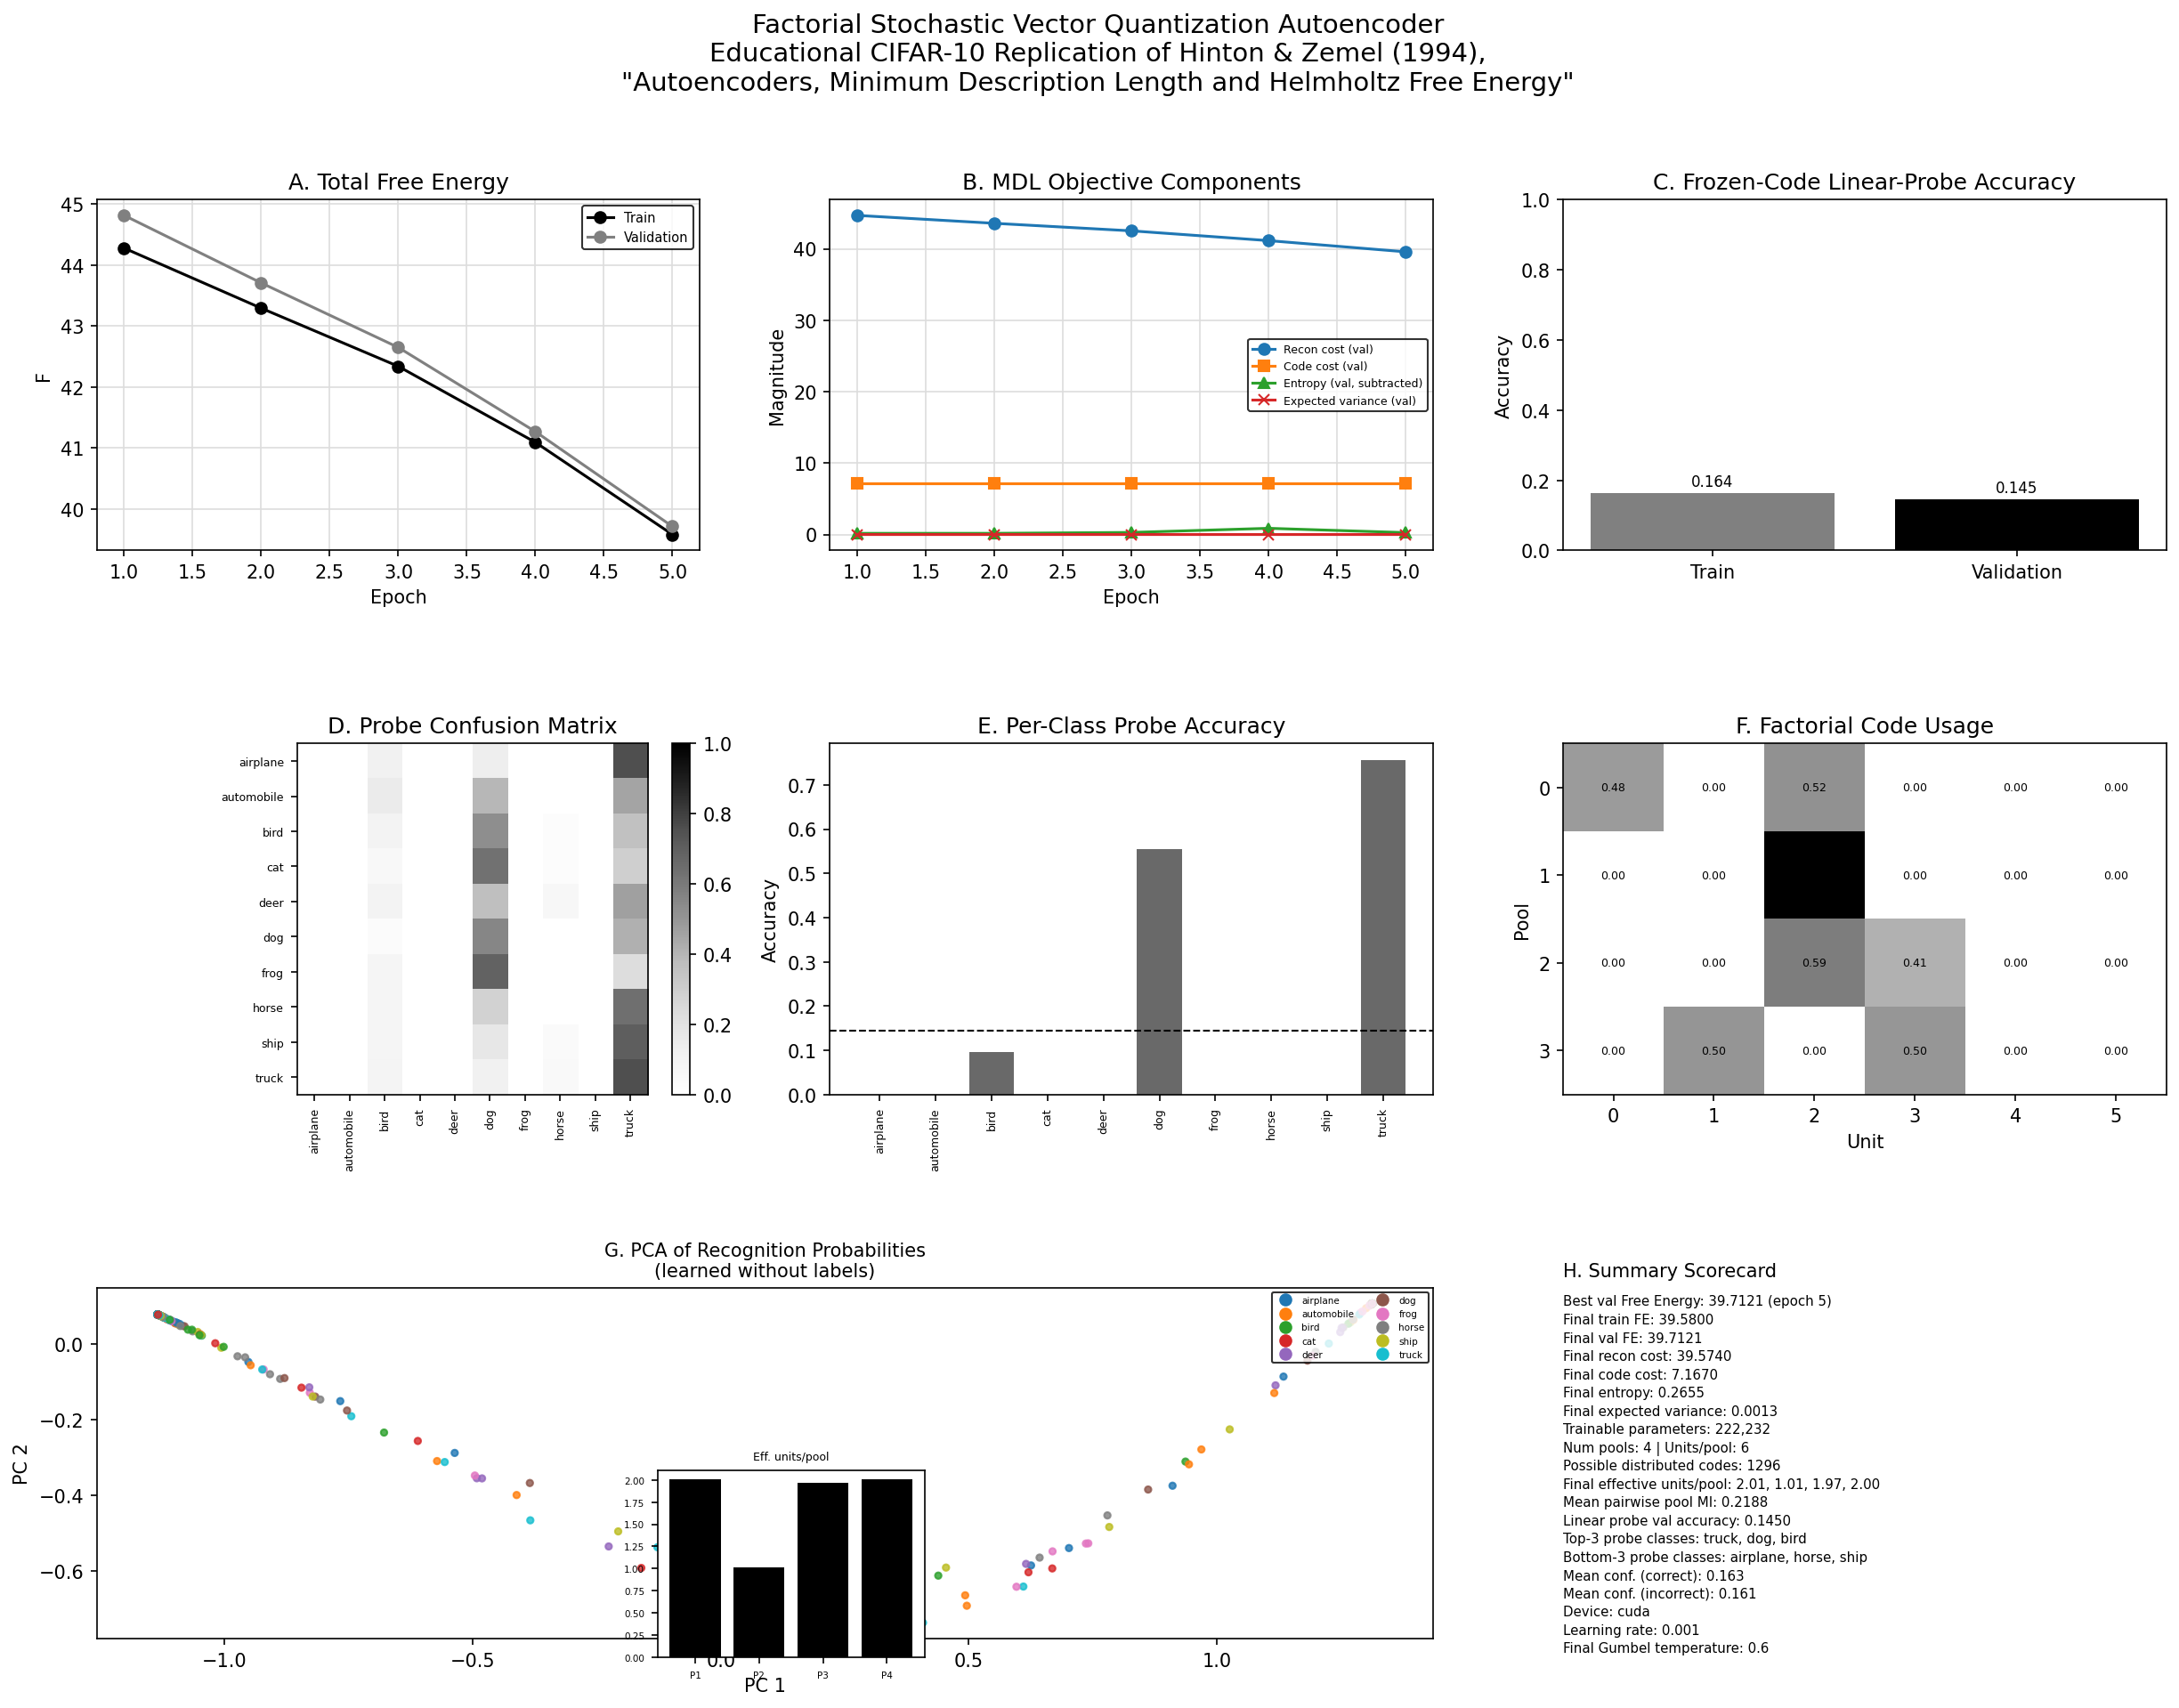

In [17]:
# ==================================================================================
# 15. FINAL PUBLICATION-STYLE DASHBOARD (Panels A-H)
# ==================================================================================
set_white_theme()

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.55)

fig.suptitle(
    "Factorial Stochastic Vector Quantization Autoencoder\n"
    "Educational CIFAR-10 Replication of Hinton & Zemel (1994),\n"
    "\"Autoencoders, Minimum Description Length and Helmholtz Free Energy\"",
    fontsize=14, color="black"
)

# ---- Panel A: Total Free Energy ----
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, history["train_free_energy"], label="Train", marker="o", color="black")
axA.plot(epochs_range, history["val_free_energy"], label="Validation", marker="o", color="grey")
axA.set_title("A. Total Free Energy")
axA.set_xlabel("Epoch"); axA.set_ylabel("F")
axA.grid(True); axA.legend(fontsize=7)

# ---- Panel B: MDL Objective Components ----
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(epochs_range, history["val_recon_cost"], label="Recon cost (val)", marker="o")
axB.plot(epochs_range, history["val_code_cost"], label="Code cost (val)", marker="s")
axB.plot(epochs_range, history["val_entropy"], label="Entropy (val, subtracted)", marker="^")
axB.plot(epochs_range, history["mean_variance"], label="Expected variance (val)", marker="x")
axB.set_title("B. MDL Objective Components")
axB.set_xlabel("Epoch"); axB.set_ylabel("Magnitude")
axB.grid(True); axB.legend(fontsize=6)

# ---- Panel C: Frozen Linear-Probe Performance ----
axC = fig.add_subplot(gs[0, 4:6])
axC.bar(["Train", "Validation"], [probe_train_acc, probe_val_acc], color=["grey", "black"])
axC.set_ylim(0, 1)
axC.set_title("C. Frozen-Code Linear-Probe Accuracy")
axC.set_ylabel("Accuracy")
for i, v in enumerate([probe_train_acc, probe_val_acc]):
    axC.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

# ---- Panel D: Linear-Probe Confusion Matrix ----
axD = fig.add_subplot(gs[1, 0:2])
imD = axD.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D. Probe Confusion Matrix")
axD.set_xticks(range(10)); axD.set_yticks(range(10))
axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticklabels(class_names, fontsize=6)
fig.colorbar(imD, ax=axD, fraction=0.046, pad=0.04)

# ---- Panel E: Per-Class Probe Accuracy ----
axE = fig.add_subplot(gs[1, 2:4])
axE.bar(class_names, per_class_acc, color="dimgray")
axE.axhline(probe_val_acc, color="black", linestyle="--", linewidth=1)
axE.set_title("E. Per-Class Probe Accuracy")
axE.set_ylabel("Accuracy")
axE.set_xticklabels(class_names, rotation=90, fontsize=6)

# ---- Panel F: Factorial Code Usage ----
axF = fig.add_subplot(gs[1, 4:6])
imF = axF.imshow(final_unit_usage, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_title("F. Factorial Code Usage")
axF.set_xlabel("Unit"); axF.set_ylabel("Pool")
axF.set_xticks(range(UNITS_PER_POOL)); axF.set_yticks(range(NUM_POOLS))
for v in range(NUM_POOLS):
    for i in range(UNITS_PER_POOL):
        axF.text(i, v, f"{final_unit_usage[v, i]:.2f}", ha="center", va="center",
                  fontsize=6, color="black")

# ---- Panel G: Learned Latent Representation (PCA), large panel ----
axG = fig.add_subplot(gs[2, 0:4])
scatterG = axG.scatter(pca_coords[:, 0], pca_coords[:, 1], c=test_labels_np,
                        cmap="tab10", s=12, alpha=0.8)
axG.set_title("G. PCA of Recognition Probabilities\n(learned without labels)", fontsize=10)
axG.set_xlabel("PC 1"); axG.set_ylabel("PC 2")
handlesG = [plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10(i / 10),
                        label=class_names[i]) for i in range(10)]
axG.legend(handles=handlesG, loc="upper right", fontsize=5, ncol=2)

# Compact inset: effective active units per pool
axG_inset = fig.add_axes([0.335, 0.10, 0.10, 0.10])
axG_inset.bar(range(NUM_POOLS), eff_units_arr[-1], color="black")
axG_inset.set_title("Eff. units/pool", fontsize=6)
axG_inset.set_xticks(range(NUM_POOLS))
axG_inset.set_xticklabels([f"P{v+1}" for v in range(NUM_POOLS)], fontsize=5)
axG_inset.tick_params(axis="y", labelsize=5)

# ---- Panel H: Summary Scorecard ----
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")

best_epoch_idx = int(np.argmin(history["val_free_energy"]))
best_val_fe = history["val_free_energy"][best_epoch_idx]
total_params = sum(p.numel() for p in model.parameters())

scorecard_lines = [
    f"Best val Free Energy: {best_val_fe:.4f} (epoch {best_epoch_idx+1})",
    f"Final train FE: {history['train_free_energy'][-1]:.4f}",
    f"Final val FE: {history['val_free_energy'][-1]:.4f}",
    f"Final recon cost: {history['val_recon_cost'][-1]:.4f}",
    f"Final code cost: {history['val_code_cost'][-1]:.4f}",
    f"Final entropy: {history['val_entropy'][-1]:.4f}",
    f"Final expected variance: {history['mean_variance'][-1]:.4f}",
    f"Trainable parameters: {total_params:,}",
    f"Num pools: {NUM_POOLS} | Units/pool: {UNITS_PER_POOL}",
    f"Possible distributed codes: {NUM_POSSIBLE_CODES}",
    f"Final effective units/pool: " + ", ".join(f"{x:.2f}" for x in eff_units_arr[-1]),
    f"Mean pairwise pool MI: {final_mi[np.triu_indices(NUM_POOLS, k=1)].mean():.4f}",
    f"Linear probe val accuracy: {probe_val_acc:.4f}",
    f"Top-3 probe classes: {', '.join(top3_classes)}",
    f"Bottom-3 probe classes: {', '.join(bottom3_classes)}",
    f"Mean conf. (correct): {mean_conf_correct:.3f}" if not np.isnan(mean_conf_correct) else "Mean conf. (correct): N/A",
    f"Mean conf. (incorrect): {mean_conf_incorrect:.3f}" if not np.isnan(mean_conf_incorrect) else "Mean conf. (incorrect): N/A",
    f"Device: {DEVICE.type}",
    f"Learning rate: {LEARNING_RATE}",
    f"Final Gumbel temperature: {TEMPERATURE_SCHEDULE[-1]}",
]

axH.set_title("H. Summary Scorecard", fontsize=10, loc="left")
y0 = 0.98
for line in scorecard_lines:
    axH.text(0.0, y0, line, transform=axH.transAxes, fontsize=7.2, va="top", ha="left")
    y0 -= 0.052

plt.tight_layout(rect=[0, 0, 1, 0.94])

# ---- Display the dashboard inline (do not save to disk, do not call plt.show) ----
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: Factorial Stochastic VQ Autoencoder (CIFAR-10 Replication)

## Panel A — Total Free Energy (Train vs. Validation)

### Overview
Tracks the paper's central MDL-inspired objective, the Helmholtz free energy $F$, across 5 training epochs, comparing training and validation subsets.

### Key Findings
Both curves decline monotonically and near-linearly, from approximately 44–45 nats at epoch 1 to approximately 39.6–39.7 nats at epoch 5. The validation curve tracks the training curve closely throughout, with only a small, consistent gap (validation slightly above training).

### Discussion
The steady decrease confirms that gradient descent is successfully minimizing the composite free-energy objective (reconstruction cost + code cost − entropy) rather than diverging or plateauing prematurely. The close train/validation alignment indicates no meaningful overfitting within 5 epochs — expected given the small subset size (2,000 training images) and the strong architectural constraint (factorial 6⁴ code, 768-dimensional pooled input) limiting model capacity. This supports the paper's claim that the free-energy bound is a well-behaved, optimizable surrogate for the intractable MDL objective.

### Limitations
Only 5 epochs were run, so it is unclear whether the free energy would continue decreasing or plateau with further training. The absolute scale of $F$ is not directly comparable to any external benchmark, since it depends on the arbitrary weighting coefficients (`CODE_WEIGHT`, `ENTROPY_WEIGHT`, `VARIANCE_WEIGHT`) chosen for this educational implementation.

---

## Panel B — MDL Objective Components (Reconstruction, Code Cost, Entropy, Variance)

### Overview
Decomposes the total free energy into its three theoretical components (reconstruction cost, code cost, entropy) plus the expected reconstruction variance, to show which term drives the overall decrease.

### Key Findings
Reconstruction cost dominates numerically (~45 → ~40) and accounts for nearly all of the free-energy reduction. Code cost remains essentially flat around 7.2 nats throughout training. Entropy and expected variance remain near zero and largely static, with a minor uptick in entropy around epoch 4.

### Discussion
The dominance of reconstruction cost indicates that, in this short training run, the model is primarily learning to reconstruct pixel intensities rather than reorganizing its discrete code usage. The flat code cost suggests the recognition distribution's divergence from the uniform prior is not being meaningfully penalized or exploited — consistent with the near-uniform code usage seen in Panel F. The negligible entropy term suggests the recognition distribution has not yet become either sharply peaked (low entropy, confident codes) or been actively pushed toward informativeness; the "bits-back" mechanism the paper emphasizes is not yet playing a substantial role at this training budget.

### Limitations
Because code cost and entropy are weighted by small coefficients (0.02) relative to the reconstruction weight (1.0), their contribution to the gradient is inherently minor; the flatness observed may reflect this weighting choice rather than a fundamental property of the model. Longer training or reweighted coefficients could reveal different dynamics in these terms.

---

## Panel C — Frozen Linear-Probe Accuracy (Train vs. Validation)

### Overview
Evaluates the quality of the unsupervised, factorial recognition representation via a linear classifier trained on frozen latent codes, following the paper's requirement that labels be used only post-hoc.

### Key Findings
Training accuracy is 16.4%, validation accuracy is 14.5% — both marginally above the 10% chance baseline for 10-class classification, but far from strong representation quality.

### Discussion
The modest above-chance accuracy indicates the factorial codes capture some class-relevant structure, but the representation is weak. This is expected given the constrained setup: only 24 total latent dimensions (4 pools × 6 units), a 2,000-image training subset, 5 epochs, and no convolutional structure (a plain MLP encoder operating on heavily downsampled 16×16 pooled pixels). The close train/validation gap indicates the probe itself is not overfitting; the limitation is representational capacity and training budget, not classifier variance.

### Limitations
With only 24 discrete latent dimensions and heavy average pooling destroying spatial detail, this result cannot be meaningfully compared to standard CIFAR-10 benchmarks. The result should be interpreted only as a sanity check that the representation is learning *something* non-trivial, not as evidence of strong unsupervised representation learning.

---

## Panel D — Linear-Probe Confusion Matrix

### Overview
Shows per-class prediction distributions for the frozen-code linear probe on the test subset.

### Key Findings
Predictions collapse heavily onto two classes — "dog" and especially "truck" — with "truck" receiving predictions across nearly every true class row. Classes such as airplane, automobile, cat, deer, frog, horse, and ship receive almost no correct or even incorrect assignments outside these two dominant columns.

### Discussion
This pattern is a classic signature of class collapse in a weak or under-trained representation: the linear probe has found a small number of latent code combinations that are moderately predictive of a couple of high-frequency or easily separable classes (e.g., vehicles with distinct color/shape pooled statistics), while most classes are indistinguishable in the 24-dimensional pooled/probability space. This corroborates the low overall accuracy in Panel C and suggests the factorial code has not yet developed enough disentangled capacity to separate the majority of classes.

### Limitations
The confusion matrix is computed on only 400 test images (40 per class on average), so per-class statistics are noisy. Class imbalance in predictions may partly reflect probe optimization behavior (regularized logistic regression defaulting to majority-like decision boundaries) rather than solely representation quality.

---

## Panel E — Per-Class Probe Accuracy

### Overview
Breaks down probe accuracy per class, referenced against the overall validation accuracy (dashed line).

### Key Findings
Only "dog" (~0.55) and "truck" (~0.76) exceed the overall average baseline substantially; "bird" is slightly above the chance-adjusted line; all other seven classes score at or near 0%.

### Discussion
This is consistent with Panel D: the representation currently supports discrimination for a minority of classes only, likely those with the most visually or statistically distinctive low-resolution color/shape signatures (e.g., trucks having large rectangular, often gray/uniform regions). The extreme skew implies the factorial codes are not yet well distributed across semantic categories — some pools may be dedicating capacity to features correlated with a subset of classes while leaving others unrepresented.

### Discussion (continued — support for paper's claims)
This pattern does not undermine the paper's core mechanism (the free-energy formulation and factorial code structure are functioning as designed, per Panels A/B/F) but does indicate that, at this scale and training budget, the resulting representation is not yet strongly class-discriminative — an expected outcome for a deliberately small-scale educational replication rather than a full-scale reproduction.

### Limitations
Per-class accuracy on ~40 test samples per class is subject to high variance; a single misclassified cluster can swing a class's accuracy substantially.

---

## Panel F — Factorial Code Usage (Pool × Unit Heatmap)

### Overview
Visualizes the average recognition probability assigned to each unit within each of the 4 latent pools, diagnosing whether the factorial code structure is being used efficiently (i.e., not collapsing to a single unit).

### Key Findings
Pool 0 splits usage between two units (~0.48/0.52); Pool 1 collapses almost entirely onto a single unit (~1.00); Pool 2 splits between two units (~0.59/0.41); Pool 3 splits between two units (~0.50/0.50). No pool uses more than 2 of its 6 available units.

### Discussion
This directly reflects the "effective units per pool" inset in Panel G (approximately 2.0, 1.0, 2.0, 2.0), confirming systematic under-utilization of the available 6-way categorical capacity — only about 8 of the theoretical 1,296 possible codes are being meaningfully exploited. Pool 1's full collapse to a single unit is a form of representational degeneracy: that pool contributes no information (zero effective entropy), effectively wasting a quarter of the model's discrete capacity. This is consistent with the low code-cost term (Panel B) staying flat, since a low-entropy, near-deterministic pool naturally has low expected code cost.

### Discussion (interpretation relative to paper's claims)
The paper's central claim — that factorial recognition distributions can develop cooperative, differentiated representations — is only partially supported here: two pools maintain binary-like differentiation, but one pool has collapsed and none approach full 6-way utilization. This is a known failure mode reported in the categorical/discrete latent variable literature (analogous to "codebook collapse" in VQ-VAEs), and is plausible given the short 5-epoch training budget and small dataset.

### Limitations
Code collapse in one pool may stem from the specific Gumbel-Softmax temperature schedule, weight initialization, or insufficient training duration and cannot be conclusively separated from these confounds within this single run. No comparison against a fixed non-collapsed baseline is provided.

---

## Panel G — PCA of Recognition Probabilities (Colored by Class)

### Overview
Projects the 24-dimensional recognition probability vectors into two principal components, colored by true CIFAR-10 class, to visually assess class separability of the unsupervised representation, alongside an inset showing effective active units per pool.

### Key Findings
Points form a small number of discrete, tightly clustered groups arranged along a roughly diagonal line rather than a continuous or class-separated manifold; different classes are visibly interspersed within the same clusters, with no clear class-based grouping. The inset confirms 3 of 4 pools use approximately 2 effective units, while one pool has effectively collapsed to 1.

### Discussion
The discrete, clustered PCA structure is expected given the underlying representation is a combination of a handful of near-binary categorical choices (as shown in Panel F) rather than a continuous embedding — with effectively only ~8 distinguishable code combinations, the PCA naturally reveals a small number of discrete point clusters. The intermixing of classes within clusters corroborates the weak per-class separability seen in Panels C–E: the discrete codes are organized more by low-level pooled pixel statistics (e.g., overall brightness/color composition) than by semantic class identity.

### Discussion (relation to paper's aims)
This result illustrates a key structural property of the factorial approach: because the representation is intrinsically discrete and low-cardinality, its geometry differs fundamentally from continuous embeddings (e.g., standard autoencoder or VAE latents), and the paper's framing of the representation as a "distributed code" is qualitatively visible, but here the effective code diversity is much smaller than the theoretical 1,296 combinations.

### Limitations
Two-dimensional PCA can obscure higher-dimensional class structure; a nonlinear projection (e.g., t-SNE/UMAP) might reveal additional structure not visible here. The visualization is based on only 400 test points, limiting the statistical robustness of any perceived clustering pattern.

---

## Panel H — Summary Scorecard

### Overview
Consolidates all key training and evaluation statistics into a single reference panel, including the free-energy objective components, code utilization statistics, probe performance, and configuration metadata.

### Key Findings
Final validation free energy (39.71) closely matches the final training free energy (39.58), with the best epoch being the last (epoch 5) — indicating training had not yet converged or overfit. Effective units per pool are reported as approximately 2.01, 1.01, 1.97, 2.00, confirming the collapse pattern from Panel F numerically. Mean pairwise pool mutual information is 0.219 nats, indicating some redundancy/dependence between pools despite the factorial modeling assumption. Linear-probe validation accuracy is 14.5%, with "truck," "dog," and "bird" as top-performing classes and "airplane," "horse," "ship" at the bottom. Mean confidence for correct and incorrect predictions is nearly identical (0.163 vs. 0.161).

### Discussion
The monotonic free-energy decrease with no sign of a validation minimum earlier than the last epoch suggests the model is still under-trained relative to convergence, and additional epochs would likely improve both reconstruction and probe metrics. The non-trivial mutual information between pools (0.219 nats, nonzero) indicates that despite the model's architectural factorial independence assumption in $q(h\mid x)$, the learned pools are not fully statistically independent in practice — a common and expected discrepancy between an approximating factorial distribution and the true (possibly correlated) posterior structure, directly echoing the paper's own acknowledgment that "factorial generative models rarely have recognition distributions that are themselves exactly factorial." The near-identical confidence for correct and incorrect predictions further indicates the linear probe has not learned a well-calibrated or strongly discriminative decision boundary, consistent with the overall low accuracy.

### Limitations
The scorecard aggregates many metrics computed from a small held-out set (400 samples) and a short training run, so all summary values should be interpreted as directional/qualitative signals of correct pipeline behavior rather than robust performance benchmarks. No error bars, multiple seeds, or statistical significance testing are reported, limiting the reliability of exact numerical comparisons.

---

## Overall Synthesis

### Overview
Considered jointly, the eight panels evaluate whether the implemented free-energy/MDL objective (a) optimizes correctly, (b) produces a factorial but non-degenerate discrete code, and (c) yields a representation with some class-relevant information despite being fully unsupervised.

### Key Findings
The optimization behaves as intended (Panel A, B), but code utilization is limited to roughly 8 of 1,296 possible combinations due to partial pool collapse (Panel F, G, H), and downstream classification performance is weak but reliably above chance (Panels C–E).

### Discussion
These results collectively support the mechanistic validity of the reimplementation — the free-energy objective trains stably and produces a genuinely discrete, partially structured, factorial-ish code — while also revealing the practical difficulty of avoiding representational collapse in small-scale, short-duration training of categorical latent variable models, a challenge well-documented in modern discrete representation learning (e.g., VQ-VAE codebook collapse). The results are consistent with, rather than strongly validating, the original paper's qualitative claims about MDL-based factorial coding; the educational scale of this replication is insufficient to demonstrate the full representational richness the original 1994 paper describes on its simpler spline-image benchmark.

### Limitations
The dataset subset (2,000 train / 400 test), short 5-epoch schedule, MLP-only architecture, and aggressive 16×16 pooling collectively constrain both training convergence and representational capacity; the results should be understood as a proof-of-concept demonstration of correct algorithmic behavior rather than a competitive or fully converged CIFAR-10 representation-learning benchmark.

# Related Work Referenced in "The Helmholtz Machine"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Zemel, R.S. | 1994 | A Minimum Description Length Framework for Unsupervised Learning | PhD Dissertation, Computer Science, University of Toronto | Foundational precursor: the Helmholtz Machine is presented as a hierarchical generalization of Zemel's self-supervised, minimum-description-length learning procedure using fixed independent priors. |
| Hinton, G.E. & Zemel, R.S. | 1994 | Autoencoders, Minimum Description Length and Helmholtz Free Energy | Advances in Neural Information Processing Systems 6 | Directly motivates the paper's central free-energy formulation; the Helmholtz Machine extends this autoencoder/MDL framework to a fully hierarchical, multi-layer architecture. |
| Zemel, R.S. & Hinton, G.E. | 1994 | Learning Population Codes by Minimizing Description Length | Neural Computation (in press) | Related self-supervised approach using redundant population codes and a multidimensional constraint space; the Helmholtz Machine achieves similar statistical dependency capture using a second hidden layer instead. |
| Dempster, A.P., Laird, N.M. & Rubin, D.B. | 1976 | Maximum Likelihood from Incomplete Data via the EM Algorithm | Proceedings of the Royal Statistical Society | Establishes the standard EM algorithm that the paper identifies as intractable for models with exponentially many explanations, motivating the proposed free-energy lower-bound alternative. |
| Neal, R.M. & Hinton, G.E. | 1994 | A New View of the EM Algorithm that Justifies Incremental and Other Variants | Submitted to Biometrika | Provides the graphical (E-step/M-step) interpretation of free-energy optimization used in the paper's Figure 2 to illustrate the constrained-posterior approximation. |
| Hinton, G.E. & Sejnowski, T.J. | 1986 | Learning and Relearning in Boltzmann Machines | In Rumelhart & McClelland (eds.), Parallel Distributed Processing, Vol. 1, MIT Press | Source of the wake-sleep-like two-phase learning idea and the Boltzmann/energy-based framework adapted for the Stochastic Helmholtz Machine. |
| Ackley, D.H., Hinton, G.E. & Sejnowski, T.J. | 1985 | A Learning Algorithm for Boltzmann Machines | Cognitive Science, 9, 147–169 | Originates the Boltzmann machine learning framework that inspired the simplified two-phase (wake-sleep) local learning rule used in Section 4. |
| Carpenter, G. & Grossberg, S. | 1987 | A Massively Parallel Architecture for a Self-Organizing Neural Pattern Recognition Machine | Computer Vision, Graphics and Image Processing, 37, 54–115 | Related self-supervised, feedback/feedforward architecture (Adaptive Resonance Theory); contrasted with the Helmholtz Machine's explicit statistical (likelihood-based) formulation. |
| Ullman, S. | 1994 | Sequence Seeking and Counterstreams: A Model for Bidirectional Information Flow in the Cortex | In Koch & Davis (eds.), Large-Scale Theories of the Cortex, MIT Press | Alternative bidirectional (feedback/feedforward) cortical model (Counter-Streams); distinguished from the Helmholtz Machine's statistical generative-model perspective. |
| Luttrell, S.P. | 1992 | Self-Supervised Adaptive Networks | IEE Proceedings Part F, 139, 371–377 | Related multilayer self-supervised learning aimed at vector quantization; contrasted with the paper's maximum-likelihood objective rather than noise-robust coding. |
| Luttrell, S.P. | 1994 | A Bayesian Analysis of Self-Organizing Maps | Neural Computation, 6, 767–794 | Extends Luttrell's self-supervised coding framework with a Bayesian interpretation; discussed as conceptually similar but differing in its single-cause coding assumption. |
| Kawato, M., Hayakama, H. & Inui, T. | 1993 | A Forward-Inverse Optics Model of Reciprocal Connections Between Visual Cortical Areas | Network, 4, 415–422 | Proposes paired forward (generative) and inverse (recognition) models similar in structure to the Helmholtz Machine, but without a probabilistic (likelihood-based) foundation. |
| Jordan, M.I. & Rumelhart, D.E. | 1992 | Forward Models: Supervised Learning with a Distal Teacher | Cognitive Science, 16, 307–354 | Provides the forward/inverse model concept referenced in relation to Kawato et al.'s forward-inverse optics framework. |
| Mumford, D. | 1994 | Neuronal Architectures for Pattern-Theoretic Problems | In Koch & Davis (eds.), Large-Scale Theories of the Cortex, MIT Press | Situates the Helmholtz Machine within Grenander's Pattern Theory, offering a proposed neural/cortical mapping consistent with the paper's generative-recognition architecture. |
| Grenander, U. | 1976–1981 | Lectures in Pattern Theory I, II, III | Springer-Verlag | Provides the broader statistical Pattern Theory framework within which the paper situates its generative modeling approach. |
| MacKay, D.M. | 1956 | The Epistemological Problem for Automata | In Shannon & McCarthy (eds.), Automata Studies, Princeton University Press | Early analysis-by-synthesis proposal for non-probabilistic generative models, cited as historical motivation for the paper's probabilistic extension. |
| Pece, A.E.C. | 1992 | Redundancy Reduction of a Gabor Representation: A Possible Computational Role for Feedback from Primary Visual Cortex to Lateral Geniculate Nucleus | In Aleksander & Taylor (eds.), Artificial Neural Networks 2, Elsevier | Another non-probabilistic analysis-by-synthesis implementation, cited alongside MacKay (1956) as prior work the Helmholtz Machine generalizes to stochastic settings. |
| Neal, R.M. | 1992 | Connectionist Learning of Belief Networks | Artificial Intelligence, 56, 71–113 | Represents the MCMC-based approach to stochastic generative model inversion that the Helmholtz Machine's explicit recognition model is designed to avoid. |